In [1]:
import os,glob
import numpy as np 
import pandas as pd
import seaborn as sns
from brain2behaviour.dataset import BrainBehaviorDataset
from brain2behaviour.preprocessing import clean_fold
from brain2behaviour.Linear.CPM_classic import sum_features4CPM


In [2]:
import json
def load_dict_from_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:
schaefer400=BrainBehaviorDataset.load('<distance pkl>')
featsEdu_dist=load_dict_from_json(f'./data/results/Reading_SES_DistanceCentroid_cpm_analysis/ds_permed0000_stable.json')


schaefer400fc=BrainBehaviorDataset.load('<FC pkl>')
featsEdu_fc=load_dict_from_json('./data/results/Reading_SES_FC_cpm_analysis/ds_permed0000_stable.json')


schaefer400sa=BrainBehaviorDataset.load('<SA pkl>')
featsEdu_sa=load_dict_from_json('./data/results/Reading_SES_SurfaceArea_cpm_analysis/ds_permed0000_stable.json')


In [ ]:
def get_feats(ds,featset,name):
    ds.cv_folds['all']={'training':list(ds.indices),'testing':list(ds.indices)}
    ds.features=featset
    feats=sum_features4CPM(ds)
    feats.columns=[f'+ {name}',f'- {name}']
    return feats

In [6]:
feats=pd.concat([get_feats(schaefer400sa,featsEdu_sa, 'SA'),
           get_feats(schaefer400,featsEdu_dist, 'CD'), 
           get_feats(schaefer400fc,featsEdu_fc, 'FC')],axis=1)

In [8]:
corr_mat=pd.concat([schaefer400.behaviorData,feats,schaefer400.confounds.iloc[:,2:]],axis=1).corr()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
rename_dict = {
    "ReadEng_Unadj": "ORRT",
    "FS_IntraCranial_Vol": "Intracranial vol",
    "FS_BrainSeg_Vol": " Brainseg vol",
    "BPSystolic": "Systolic bp",
    "BPDiastolic": "Diastolic bp",
    "SSAGA_Income": "Income",
    "SSAGA_Educ": "Education",
    "Age_in_Yrs":'Age',
    "Larea": "Lh total sa",
    "Rarea": "Rh total sa",
}


corr_mat.rename(
    index=rename_dict,
    columns=rename_dict,inplace=True)

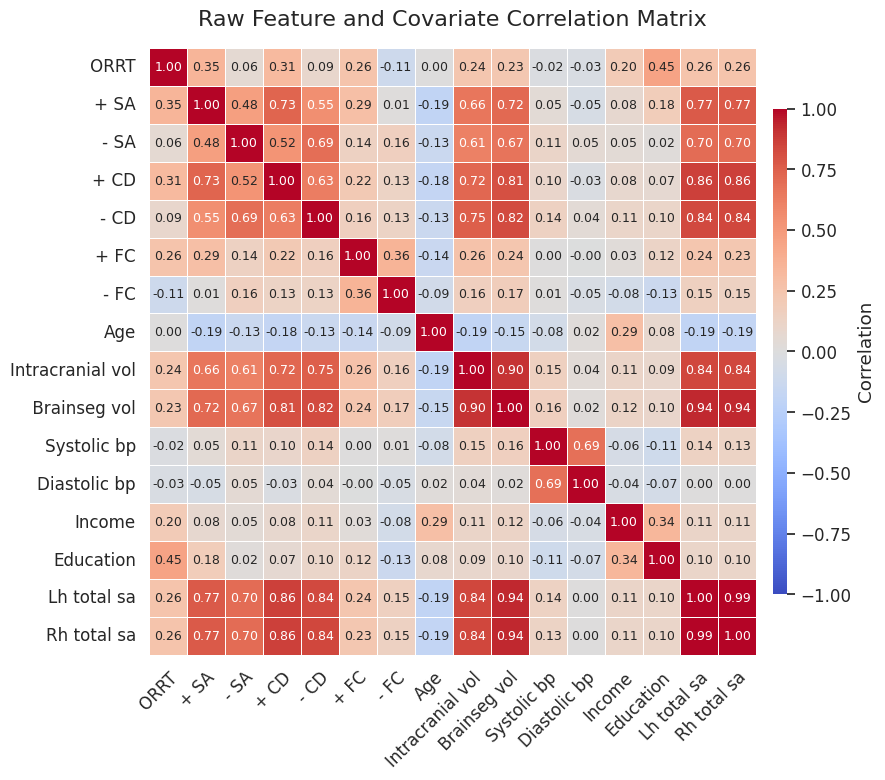

In [13]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: make labels publication-friendlier
# corr_plot = corr_mat.copy()
# corr_plot.index = corr_plot.index.str.replace("_", " ", regex=False)
# corr_plot.columns = corr_plot.columns.str.replace("_", " ", regex=False)

# Styling
sns.set_theme(style="white", font_scale=1.1)

fig, ax = plt.subplots(figsize=(10, 8))

hm = sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "aspect": 35,
        "pad": 0.02,
        "label": "Correlation"
    },
    annot_kws={"size": 9},
    ax=ax
)

ax.set_title("Raw Feature and Covariate Correlation Matrix", fontsize=16, pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Clean up spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

odir = "/well/margulies/users/mnk884/DistanceValidationOx2025/gifti_results/"
plt.savefig(
    f"{odir}/confound_heatmap_full.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()